# Autoencoder Tracking Portfolio for S&P 500

This notebook builds a sparse tracking portfolio from S&P 500 constituents using two autoencoder-based ranking ideas:

1. **Communality**: stocks with the best reconstruction R² from an autoencoder.
2. **Latent factor mapping**: stocks most correlated with the learned latent factors.

It evaluates **k = 10 to 50**, fits long-only weights on the pre-holdout period, and reports:
- Holdout tracking error
- Information ratio
- Sector drift versus the S&P 500 constituent universe


In [ ]:
!pip -q install cvxpy yfinance tqdm lxml html5lib beautifulsoup4


In [ ]:
import os
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import cvxpy as cp
import yfinance as yf

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR        = Path('/content/drive/MyDrive/Mega')
CACHE_DIR       = Path('/content/drive/MyDrive/Mega/cache')
SECTOR_CACHE    = CACHE_DIR / 'sector_map.csv'
MARKETCAP_CACHE = CACHE_DIR / 'market_caps.csv'

FIT_START  = '2020-01-01'
FIT_END    = '2024-12-31'
SEL_START  = '2025-01-01'
SEL_END    = '2025-06-30'
HOLD_START = '2025-07-01'
HOLD_END   = '2025-12-31'

K_LIST     = list(range(10, 101))  # assignment requires 10 to 100
LATENT_DIM = 12
BATCH_SIZE = 64
EPOCHS     = 120
PATIENCE   = 15
LR         = 1e-3
L2         = 1e-5


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print('Drive mount skipped:', e)

print('Data dir exists:', DATA_DIR.exists())
print('Example files:', [p.name for p in list(DATA_DIR.rglob('*.csv'))[:5]])


Mounted at /content/drive
Data dir exists: True
Example files: ['sp500_tickers_cache.csv', 'ABNB.csv', 'APP.csv', 'CARR.csv', 'CEG.csv']


In [ ]:
def load_ticker_cache(data_dir: Path, cache_name: str = 'sp500_tickers_cache.csv') -> pd.Series:
    cache_path = next(data_dir.rglob(cache_name), None)
    if cache_path is None:
        raise FileNotFoundError(f'{cache_name} not found under {data_dir}.')

    cache_df = pd.read_csv(cache_path)
    if cache_df.shape[1] != 1:
        raise ValueError(
            f'{cache_name} must have exactly one column, found {cache_df.shape[1]}: '
            f'{list(cache_df.columns)}'
        )

    cache_col = cache_df.columns[0]
    tickers = cache_df[cache_col].astype(str).str.strip()
    tickers = tickers[tickers.ne('')].drop_duplicates().reset_index(drop=True)

    print(f'Cache file: {cache_path}')
    print(f'Cache column: {cache_col}')
    print(f'Tickers in cache: {len(tickers)}')
    return tickers


def load_price_panel(
    data_dir: Path,
    benchmark_stems=('^GSPC', 'GSPC'),
    cache_name='sp500_tickers_cache.csv',
    use_cache_universe=False,
):
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory does not exist: {data_dir}')

    cache_path = next(data_dir.rglob(cache_name), None)
    cache_tickers = None
    if cache_path is not None:
        cache_df = pd.read_csv(cache_path)
        if cache_df.shape[1] != 1:
            raise ValueError(f'{cache_name} must have exactly one column, found {cache_df.shape[1]}')
        cache_tickers = set(cache_df.iloc[:, 0].astype(str).str.strip().tolist())

    all_csvs = sorted(data_dir.rglob('*.csv'))
    benchmark_path = next((p for p in all_csvs if p.stem in benchmark_stems), None)
    if benchmark_path is None:
        raise FileNotFoundError(
            f'Benchmark file not found. Looked for stems {benchmark_stems} under {data_dir}'
        )

    bench_df = pd.read_csv(benchmark_path, parse_dates=['Date'])
    bench_df = bench_df.sort_values('Date').drop_duplicates('Date', keep='last')
    if 'Close' not in bench_df.columns:
        raise ValueError(f'{benchmark_path.name} must contain a Close column')

    benchmark = (
        bench_df.set_index('Date')['Close']
        .astype(float)
        .rename('benchmark')
        .sort_index()
    )

    stock_series, loaded_files, skipped_files = [], [], []
    for fp in all_csvs:
        if fp.name in {cache_name, benchmark_path.name}:
            continue
        ticker = fp.stem
        if use_cache_universe and (cache_tickers is not None) and (ticker not in cache_tickers):
            skipped_files.append(ticker)
            continue
        try:
            df = pd.read_csv(fp, parse_dates=['Date'])
        except Exception as e:
            skipped_files.append(f'{ticker} (read error: {e})')
            continue

        if 'Date' not in df.columns:
            skipped_files.append(f'{ticker} (no Date column)')
            continue

        df = df.sort_values('Date').drop_duplicates('Date', keep='last')
        price_col = 'Adj Close' if 'Adj Close' in df.columns else ('Close' if 'Close' in df.columns else None)
        if price_col is None:
            skipped_files.append(f'{ticker} (no Close / Adj Close)')
            continue

        s = df.set_index('Date')[price_col].astype(float).rename(ticker).sort_index()
        if s.notna().sum() < 50:
            skipped_files.append(f'{ticker} (too few observations)')
            continue

        stock_series.append(s)
        loaded_files.append(ticker)

    if not stock_series:
        raise RuntimeError('No stock CSVs were loaded. Check folder structure and file format.')

    prices = pd.concat(stock_series, axis=1).sort_index()
    common_index = prices.index.intersection(benchmark.index)
    prices    = prices.loc[common_index].copy()
    benchmark = benchmark.loc[common_index].copy()
    prices    = prices.loc[benchmark.notna()]
    benchmark = benchmark.loc[benchmark.notna()]
    prices    = prices.replace([np.inf, -np.inf], np.nan)

    print(f'Benchmark file: {benchmark_path.name}')
    print(f'Loaded stock files: {len(loaded_files)}')
    print(f'Skipped files: {len(skipped_files)}')
    print(f'Price panel shape: {prices.shape}')
    print(f'Benchmark length: {len(benchmark)}')
    return prices, benchmark, loaded_files, skipped_files, benchmark_path, cache_path


print('Base dir:', DATA_DIR)
print('CSV files found:', len(list(DATA_DIR.rglob('*.csv'))))

sp500_tickers = load_ticker_cache(DATA_DIR)

prices, benchmark, loaded_files, skipped_files, benchmark_path, cache_path = load_price_panel(
    DATA_DIR, use_cache_universe=False
)

print('Prices shape:', prices.shape)
print('Universe tickers:', len(prices.columns))
print('Benchmark file:', benchmark_path)
print('Cache file:', cache_path)

extra_names = sorted(set(prices.columns) - set(sp500_tickers))
print('Extra stock files not in current cache:', len(extra_names))
print(extra_names[:40])


Base dir: /content/drive/MyDrive/Mega
CSV files found: 587
Cache file: /content/drive/MyDrive/Mega/sp500_tickers_cache.csv
Cache column: Ticker
Tickers in cache: 503
Benchmark file: ^GSPC.csv
Loaded stock files: 578
Skipped files: 7
Price panel shape: (1525, 578)
Benchmark length: 1525
Prices shape: (1525, 578)
Universe tickers: 578
Benchmark file: /content/drive/MyDrive/Mega/^GSPC.csv
Cache file: /content/drive/MyDrive/Mega/sp500_tickers_cache.csv
Extra stock files not in current cache: 75
['AAL', 'AAP', 'AIV', 'ALK', 'AMG', 'AN', 'ANF', 'ATGE', 'AYI', 'BHF', 'BWA', 'CCEP', 'CE', 'CIEN', 'CLF', 'CNX', 'COL', 'COTY', 'CPRI', 'CVG', 'DDR', 'DXC', 'FB', 'FCPT', 'FHN', 'FLR', 'FLS', 'FMC', 'FOSL', 'FTI', 'GHC', 'GME', 'GNW', 'HBI', 'HOG', 'HP', 'IAC', 'ILMN', 'INFO', 'IPGP']


In [ ]:
bench_ret   = benchmark.pct_change().rename('benchmark_ret')
stock_rets  = prices.pct_change()

aligned = stock_rets.join(bench_ret, how='inner').dropna(subset=['benchmark_ret'])
stock_ret_df = aligned.drop(columns=['benchmark_ret'])
bench_ret    = aligned['benchmark_ret']

print('Aligned return matrix:', stock_ret_df.shape)
print('Date range:', stock_ret_df.index.min().date(), '->', stock_ret_df.index.max().date())


Aligned return matrix: (1524, 578)
Date range: 2020-01-03 -> 2026-01-27


In [ ]:
pre_holdout_mask = (stock_ret_df.index >= FIT_START) & (stock_ret_df.index <= SEL_END)
coverage = stock_ret_df.loc[pre_holdout_mask].notna().mean().sort_values(ascending=False)

MIN_COVERAGE    = 0.95
eligible_tickers = coverage[coverage >= MIN_COVERAGE].index.tolist()
print('Eligible tickers:', len(eligible_tickers))

X_all = stock_ret_df[eligible_tickers].copy()
y_all = bench_ret.loc[X_all.index].copy()

fit_mask  = (X_all.index >= FIT_START)  & (X_all.index <= FIT_END)
sel_mask  = (X_all.index >= SEL_START)  & (X_all.index <= SEL_END)
hold_mask = (X_all.index >= HOLD_START) & (X_all.index <= HOLD_END)

X_fit_raw  = X_all.loc[fit_mask];   y_fit  = y_all.loc[fit_mask]
X_sel_raw  = X_all.loc[sel_mask];   y_sel  = y_all.loc[sel_mask]
X_hold_raw = X_all.loc[hold_mask];  y_hold = y_all.loc[hold_mask]

print('Fit:', X_fit_raw.shape, 'Selection:', X_sel_raw.shape, 'Holdout:', X_hold_raw.shape)

usable_cols = X_fit_raw.columns[X_fit_raw.notna().any(axis=0)].tolist()
dropped_cols = [c for c in X_fit_raw.columns if c not in usable_cols]
print('Columns dropped (all-NaN in fit):', len(dropped_cols), dropped_cols[:20])

X_fit_raw  = X_fit_raw[usable_cols]
X_sel_raw  = X_sel_raw[usable_cols]
X_hold_raw = X_hold_raw[usable_cols]

imputer = SimpleImputer(strategy='median')
X_fit  = pd.DataFrame(imputer.fit_transform(X_fit_raw),  index=X_fit_raw.index,  columns=X_fit_raw.columns)
X_sel  = pd.DataFrame(imputer.transform(X_sel_raw),      index=X_sel_raw.index,  columns=X_sel_raw.columns)
X_hold = pd.DataFrame(imputer.transform(X_hold_raw),     index=X_hold_raw.index, columns=X_hold_raw.columns)

scaler = StandardScaler()
X_fit_s  = pd.DataFrame(scaler.fit_transform(X_fit),  index=X_fit.index,  columns=X_fit.columns)
X_sel_s  = pd.DataFrame(scaler.transform(X_sel),      index=X_sel.index,  columns=X_sel.columns)
X_hold_s = pd.DataFrame(scaler.transform(X_hold),     index=X_hold.index, columns=X_hold.columns)

print('Remaining NaNs — fit:', int(X_fit.isna().sum().sum()),
      '| sel:', int(X_sel.isna().sum().sum()),
      '| hold:', int(X_hold.isna().sum().sum()))


Eligible tickers: 559
Fit: (1257, 559) Selection: (122, 559) Holdout: (128, 559)
Columns dropped (all-NaN in fit): 0 []
Remaining NaNs — fit: 0 | sel: 0 | hold: 0


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 12):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 64),        nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256),        nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z    = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


def train_autoencoder(
    X_fit_s: pd.DataFrame,
    latent_dim=12, batch_size=64, epochs=120, patience=15, lr=1e-3, l2=1e-5,
):
    n     = len(X_fit_s)
    split = int(n * 0.8)
    X_tr  = X_fit_s.iloc[:split].values.astype(np.float32)
    X_va  = X_fit_s.iloc[split:].values.astype(np.float32)

    tr_loader  = DataLoader(TensorDataset(torch.tensor(X_tr)), batch_size=batch_size, shuffle=True)
    va_tensor  = torch.tensor(X_va).to(device)

    model   = AutoEncoder(input_dim=X_fit_s.shape[1], latent_dim=latent_dim).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    loss_fn = nn.MSELoss()

    best_state, best_val, wait = None, np.inf, 0

    for epoch in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for (xb,) in tr_loader:
            xb = xb.to(device)
            opt.zero_grad()
            xhat, _ = model(xb)
            loss = loss_fn(xhat, xb)
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            xhat_va, _ = model(va_tensor)
            val_loss   = loss_fn(xhat_va, va_tensor).item()

        if val_loss < best_val - 1e-6:
            best_val   = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | train={np.mean(tr_losses):.6f} | val={val_loss:.6f}')

        if wait >= patience:
            print('Early stopping triggered.')
            break

    model.load_state_dict(best_state)
    model.eval()
    return model


model = train_autoencoder(
    X_fit_s,
    latent_dim=LATENT_DIM, batch_size=BATCH_SIZE,
    epochs=EPOCHS, patience=PATIENCE, lr=LR, l2=L2,
)
print('Autoencoder training complete.')


Using device: cpu
Epoch 001 | train=0.894645 | val=0.511706
Epoch 010 | train=0.524494 | val=0.458708
Epoch 020 | train=0.487917 | val=0.452162
Epoch 030 | train=0.448886 | val=0.446560
Epoch 040 | train=0.422975 | val=0.439838
Epoch 050 | train=0.406300 | val=0.436065
Epoch 060 | train=0.391013 | val=0.433394
Epoch 070 | train=0.386473 | val=0.432216
Epoch 080 | train=0.368456 | val=0.430437
Epoch 090 | train=0.386246 | val=0.434400
Early stopping triggered.
Autoencoder training complete.


In [ ]:
def encode_decode_df(model, X_s: pd.DataFrame):
    model.eval()
    with torch.no_grad():
        x    = torch.tensor(X_s.values.astype(np.float32), device=next(model.parameters()).device)
        xhat, z = model(x)
    xhat = pd.DataFrame(xhat.cpu().numpy(), index=X_s.index, columns=X_s.columns)
    z    = pd.DataFrame(z.cpu().numpy(),    index=X_s.index,
                        columns=[f'z{i+1}' for i in range(z.shape[1])])
    return xhat, z


X_sel_hat, Z_sel = encode_decode_df(model, X_sel_s)

communalities = {
    col: r2_score(X_sel_s[col].values, X_sel_hat[col].values)
    for col in X_sel.columns
}
communalities = pd.Series(communalities).sort_values(ascending=False)

latent_corr = pd.DataFrame(index=X_sel.columns, columns=Z_sel.columns, dtype=float)
for zc in Z_sel.columns:
    z = Z_sel[zc].values
    z = (z - z.mean()) / (z.std(ddof=1) + 1e-12)
    for c in X_sel.columns:
        x = X_sel_s[c].values
        x = (x - x.mean()) / (x.std(ddof=1) + 1e-12)
        latent_corr.loc[c, zc] = np.corrcoef(x, z)[0, 1]

latent_score = latent_corr.abs().max(axis=1).sort_values(ascending=False)

scores = pd.DataFrame({'communality': communalities, 'latent_score': latent_score}).fillna(0.0)
scores['comm_rank']    = scores['communality'].rank(method='average', ascending=True, pct=True)
scores['latent_rank']  = scores['latent_score'].rank(method='average', ascending=True, pct=True)
scores['hybrid_score'] = 0.6 * scores['comm_rank'] + 0.4 * scores['latent_rank']
scores = scores.sort_values('hybrid_score', ascending=False)

scores.head(10)


,communality,latent_score,comm_rank,latent_rank,hybrid_score
TRMB,0.837746,0.838856,0.994633,0.985689,0.991055
SWK,0.780650,0.859680,0.969589,0.998211,0.981038
MET,0.853956,0.817880,1.000000,0.951699,0.980680
TROW,0.774043,0.852086,0.966011,0.994633,0.977460
PH,0.810463,0.822818,0.983900,0.960644,0.974597
DOV,0.795300,0.824364,0.980322,0.964222,0.973882
PFG,0.833695,0.811286,0.991055,0.942755,0.971735
AXP,0.771073,0.843633,0.958855,0.991055,0.971735
EMR,0.771956,0.832692,0.960644,0.978533,0.967800
ITW,0.825109,0.808276,0.989267,0.924866,0.963506


In [ ]:
def pick_subset(scores: pd.DataFrame, k: int, method: str):
    if method == 'communality':
        return scores['communality'].sort_values(ascending=False).head(k).index.tolist()
    if method == 'latent':
        return scores['latent_score'].sort_values(ascending=False).head(k).index.tolist()
    if method == 'hybrid':
        return scores['hybrid_score'].sort_values(ascending=False).head(k).index.tolist()
    raise ValueError('method must be one of: communality, latent, hybrid')


def fit_simplex_tracking_weights(X_train: pd.DataFrame, y_train: pd.Series, l2=1e-6):
    idx     = X_train.index.intersection(y_train.index)
    X_train = X_train.loc[idx];  y_train = y_train.loc[idx]
    Xv, yv  = X_train.values.astype(float), y_train.values.astype(float)
    k       = Xv.shape[1]
    w       = cp.Variable(k, nonneg=True)

    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Xv @ w - yv) + l2 * cp.sum_squares(w)),
        [cp.sum(w) == 1]
    )
    solved = False
    for solver in [cp.OSQP, cp.ECOS, cp.SCS]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None:
                solved = True
                break
        except Exception:
            continue

    if not solved or w.value is None:
        return pd.Series(np.ones(k) / k, index=X_train.columns)

    ww = np.clip(w.value, 0, None)
    s  = ww.sum()
    ww = ww / s if s > 0 else np.ones(k) / k
    return pd.Series(ww, index=X_train.columns)


def portfolio_returns(X: pd.DataFrame, weights: pd.Series):
    cols = X.columns.intersection(weights.index)
    return X[cols].mul(weights[cols], axis=1).sum(axis=1)


def compute_metrics(Xdf, yser, weights):
    idx  = Xdf.index.intersection(yser.index)
    Xdf  = Xdf.loc[idx];  yser = yser.loc[idx]
    rp   = portfolio_returns(Xdf, weights)
    active = rp - yser
    te  = active.std(ddof=1) * np.sqrt(252)
    ir  = (active.mean() / (active.std(ddof=1) + 1e-12)) * np.sqrt(252)
    return te, ir


def evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold):
    def align(X, y):
        idx = X.index.intersection(y.index)
        return X.loc[idx], y.loc[idx]

    Xf, yf = align(X_fit[subset],  y_fit)
    Xs, ys = align(X_sel[subset],  y_sel)
    Xh, yh = align(X_hold[subset], y_hold)

    X_train = pd.concat([Xf, Xs]);  y_train = pd.concat([yf, ys])
    w = fit_simplex_tracking_weights(X_train, y_train)

    fit_te,  fit_ir  = compute_metrics(Xf, yf, w)
    sel_te,  sel_ir  = compute_metrics(Xs, ys, w)
    hold_te, hold_ir = compute_metrics(Xh, yh, w)

    return dict(
        weights=w,
        fit_te=fit_te,   sel_te=sel_te,   hold_te=hold_te,
        fit_ir=fit_ir,   sel_ir=sel_ir,   hold_ir=hold_ir,
    )


In [ ]:
all_rows     = []
weight_store = {}

for k in tqdm(K_LIST, desc='Evaluating k'):
    for method in ['communality', 'latent', 'hybrid']:
        subset = pick_subset(scores, k, method)
        if not subset:
            continue
        metrics = evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold)
        all_rows.append(dict(
            k=k, method=method, n_selected=len(subset),
            fit_te_ann=metrics['fit_te'],   sel_te_ann=metrics['sel_te'],   hold_te_ann=metrics['hold_te'],
            fit_ir_ann=metrics['fit_ir'],   sel_ir_ann=metrics['sel_ir'],   hold_ir_ann=metrics['hold_ir'],
        ))
        weight_store[(method, k)] = metrics['weights']

results = pd.DataFrame(all_rows)
if results.empty:
    raise RuntimeError('Results are empty — check scores generation.')

results = results.sort_values(['method', 'k']).reset_index(drop=True)
print('Results shape:', results.shape)
results.head()


Evaluating k:   0%|          | 0/91 [00:00<?, ?it/s]

Results shape: (273, 9)


,k,method,n_selected,fit_te_ann,sel_te_ann,hold_te_ann,fit_ir_ann,sel_ir_ann,hold_ir_ann
0,10,communality,10,0.138293,0.123192,0.135901,0.071349,-0.595314,-0.891181
1,11,communality,11,0.138293,0.123192,0.135901,0.071349,-0.595314,-0.891181
2,12,communality,12,0.135231,0.115860,0.140107,0.051437,-0.743468,-0.823252
3,13,communality,13,0.126304,0.115452,0.124992,0.199938,-0.023918,0.188375
4,14,communality,14,0.126304,0.115452,0.124992,0.199938,-0.023918,0.188375


In [ ]:
pivot = results.pivot(index='k', columns='method', values=['hold_te_ann', 'hold_ir_ann'])
pivot.round(4)


hold_te_ann                 hold_ir_ann                
method communality  hybrid  latent communality  hybrid  latent
k                                                             
10          0.1359  0.1308  0.1221     -0.8912 -0.7206 -1.7237
11          0.1359  0.1202  0.1222     -0.8912  0.0253 -1.9038
12          0.1401  0.1202  0.1090     -0.8233  0.0253 -1.2828
13          0.1250  0.1212  0.1081      0.1884 -0.0369 -1.3870
14          0.1250  0.1155  0.1081      0.1884  0.3744 -1.3870
..             ...     ...     ...         ...     ...     ...
96          0.0721  0.0606  0.0606     -0.4084 -0.1460 -1.1331
97          0.0721  0.0606  0.0604     -0.4084 -0.1460 -0.9890
98          0.0721  0.0606  0.0604     -0.4091 -0.1460 -0.9890
99          0.0721  0.0606  0.0563     -0.5044 -0.1460 -1.2733
100         0.0721  0.0606  0.0563     -0.5044 -0.1460 -1.2733

[91 rows x 6 columns]

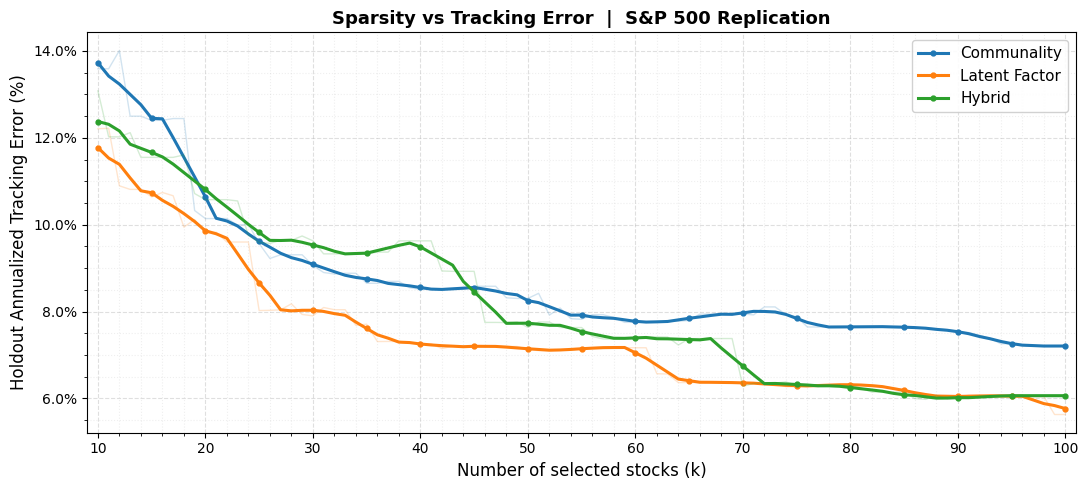

In [ ]:
COLORS  = {'communality': '#1f77b4', 'latent': '#ff7f0e', 'hybrid': '#2ca02c'}
LABELS  = {'communality': 'Communality', 'latent': 'Latent Factor', 'hybrid': 'Hybrid'}
WINDOW  = 5

fig, ax = plt.subplots(figsize=(11, 5))

for method in ['communality', 'latent', 'hybrid']:
    sub  = results[results['method'] == method].sort_values('k')
    raw  = sub['hold_te_ann'].values
    k    = sub['k'].values
    smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values
    ax.plot(k, raw * 100, color=COLORS[method], alpha=0.20, linewidth=1)
    ax.plot(k, smoothed * 100, color=COLORS[method], linewidth=2.2,
            label=LABELS[method], marker='o', markersize=3.5, markevery=5)

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Tracking Error (%)', fontsize=12)
ax.set_title('Sparsity vs Tracking Error  |  S&P 500 Replication', fontsize=13, fontweight='bold')
ax.set_xlim(results['k'].min() - 1, results['k'].max() + 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()


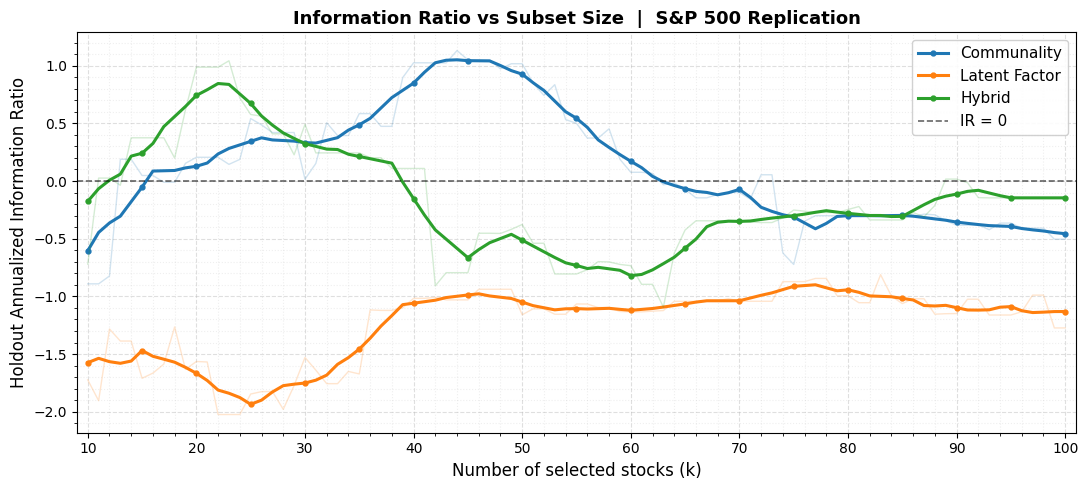

In [ ]:
COLORS  = {'communality': '#1f77b4', 'latent': '#ff7f0e', 'hybrid': '#2ca02c'}
LABELS  = {'communality': 'Communality', 'latent': 'Latent Factor', 'hybrid': 'Hybrid'}
WINDOW  = 7

fig, ax = plt.subplots(figsize=(11, 5))

for method in ['communality', 'latent', 'hybrid']:
    sub  = results[results['method'] == method].sort_values('k')
    raw  = sub['hold_ir_ann'].values
    k    = sub['k'].values
    smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values

    ax.plot(k, raw,      color=COLORS[method], alpha=0.20, linewidth=1)
    ax.plot(k, smoothed, color=COLORS[method], linewidth=2.2,
            label=LABELS[method], marker='o', markersize=3.5, markevery=5)

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='IR = 0')

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Information Ratio', fontsize=12)
ax.set_title('Information Ratio vs Subset Size  |  S&P 500 Replication', fontsize=13, fontweight='bold')
ax.set_xlim(results['k'].min() - 1, results['k'].max() + 1)
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()


In [ ]:
hyb      = results[(results['method'] == 'hybrid') & (results['k'] <= 50)].copy()
best_row = hyb.loc[hyb['hold_te_ann'].idxmin()]
best_k   = int(best_row['k'])
print('Best hybrid k by holdout TE:', best_k)
print(best_row)

best_weights = weight_store[('hybrid', best_k)]
best_subset  = best_weights.index.tolist()

best_selection = pd.DataFrame({
    'ticker':       best_weights.index,
    'weight':       best_weights.values,
    'communality':  scores.loc[best_weights.index, 'communality'].values,
    'latent_score': scores.loc[best_weights.index, 'latent_score'].values,
    'hybrid_score': scores.loc[best_weights.index, 'hybrid_score'].values,
}).sort_values('weight', ascending=False)

best_selection.head(20)


Best hybrid k by holdout TE: 50
k                    50
method           hybrid
n_selected           50
fit_te_ann     0.074648
sel_te_ann     0.081117
hold_te_ann    0.076371
fit_ir_ann     0.351737
sel_ir_ann     0.909276
hold_ir_ann   -0.376677
Name: 131, dtype: object


,ticker,weight,communality,latent_score,hybrid_score
45,WEC,0.160994,0.736429,0.792348,0.904472
30,V,0.148909,0.721943,0.851675,0.934884
41,ROP,0.121987,0.697843,0.824313,0.906619
3,TROW,0.062459,0.774043,0.852086,0.977460
29,KEYS,0.060183,0.755015,0.809451,0.935599
17,MPWR,0.045174,0.747525,0.824533,0.947764
10,TEL,0.040459,0.768668,0.825439,0.962075
42,AME,0.039495,0.728395,0.796805,0.905546
0,TRMB,0.033605,0.837746,0.838856,0.991055
22,CAT,0.032990,0.760090,0.810953,0.943113


Loaded sector map from cache (unknown rate: 0.9%)
Unknown sector ratio: 0.89%
Loaded market caps from cache (fill rate: 99.3%)
Sector weight mode: market-cap weighted
Top sectors:


,market_cap
sector,
Technology,0.302430
Communication Services,0.164532
Financial Services,0.121099
Consumer Cyclical,0.096971
Healthcare,0.087617
Industrials,0.073892
Consumer Defensive,0.056540
Energy,0.036462
Utilities,0.021816


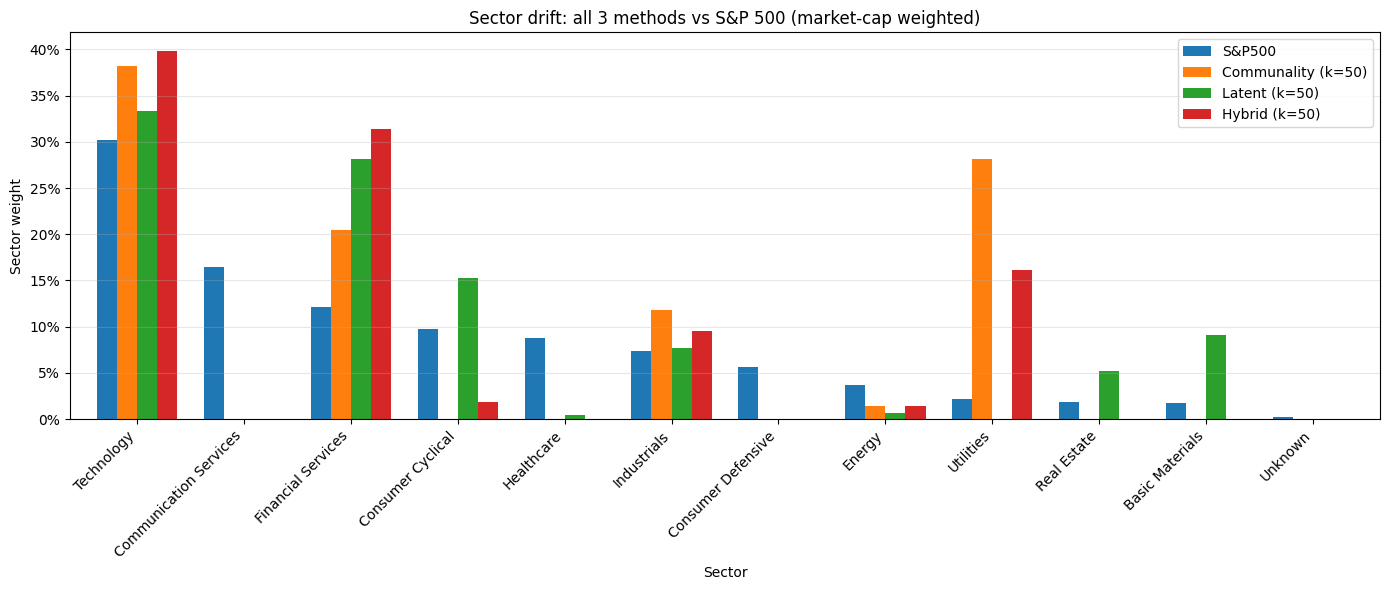

,S&P500,Communality (k=50),Latent (k=50),Hybrid (k=50)
sector,,,,
Technology,0.3024,0.3820,0.3334,0.3985
Communication Services,0.1645,0.0000,0.0000,0.0000
Financial Services,0.1211,0.2050,0.2814,0.3134
Consumer Cyclical,0.0970,0.0002,0.1530,0.0182
Healthcare,0.0876,0.0000,0.0047,0.0000
Industrials,0.0739,0.1177,0.0769,0.0952
Consumer Defensive,0.0565,0.0000,0.0000,0.0000
Energy,0.0365,0.0142,0.0069,0.0136
Utilities,0.0218,0.2809,0.0000,0.1610


In [ ]:
from IPython.display import display

CACHE_DIR.mkdir(parents=True, exist_ok=True)

def get_sp500_sector_map(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            unknown_rate = (cached['sector'] == 'Unknown').mean()
            if unknown_rate < 0.10:
                print(f"Loaded sector map from cache (unknown rate: {unknown_rate:.1%})")
                return cached
            else:
                print(f"Cache too stale ({unknown_rate:.1%} unknown), refetching...")

    sector_map = {}

    try:
        wiki_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        tables = pd.read_html(wiki_url)
        wiki = tables[0]
        sym_col  = [c for c in wiki.columns if 'symbol' in c.lower() or 'ticker' in c.lower()][0]
        sec_col  = [c for c in wiki.columns if 'gics sector' in c.lower() or 'sector' in c.lower()][0]
        for _, row in wiki.iterrows():
            sym = str(row[sym_col]).strip().replace('.', '-')  # BRK.B → BRK-B
            sector_map[sym] = str(row[sec_col]).strip()
        print(f"Wikipedia: mapped {len(sector_map)} tickers")
    except Exception as e:
        print(f"Wikipedia fetch failed: {e}")

    still_unknown = [t for t in tickers if sector_map.get(t, 'Unknown') == 'Unknown']
    if still_unknown:
        print(f"yfinance fallback for {len(still_unknown)} tickers...")
        def fetch_sector_yf(t):
            try:
                info = yf.Ticker(t).get_info()
                return t, info.get('sector') or 'Unknown'
            except Exception:
                return t, 'Unknown'
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futs = {ex.submit(fetch_sector_yf, t): t for t in still_unknown}
            for fut in tqdm(as_completed(futs), total=len(futs), desc='yfinance sector fallback'):
                t, s = fut.result()
                sector_map[t] = s

    df = pd.DataFrame([
        {'ticker': t, 'sector': sector_map.get(t, 'Unknown')} for t in tickers
    ])
    unknown_rate = (df['sector'] == 'Unknown').mean()
    print(f"Final unknown rate: {unknown_rate:.1%}")

    try:
        df.to_csv(cache_path, index=False)
    except Exception as e:
        print("Warning: could not save sector cache:", e)

    return df

def get_market_caps(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            fill_rate = cached['market_cap'].notna().mean()
            if fill_rate >= 0.5:
                print(f"Loaded market caps from cache (fill rate: {fill_rate:.1%})")
                return cached
            else:
                print(f"Cache fill rate too low ({fill_rate:.1%}), refetching...")

    def fetch_one(t):
        try:
            tk = yf.Ticker(t)
            fi = getattr(tk, 'fast_info', None)
            mc = getattr(fi, 'market_cap', np.nan) if fi is not None else np.nan
            if pd.isna(mc):
                info = tk.get_info()
                mc = info.get('marketCap', np.nan)
        except Exception:
            mc = np.nan
        return {'ticker': t, 'market_cap': mc}

    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_one, t): t for t in tickers}
        for fut in tqdm(as_completed(futs), total=len(futs), desc='Fetching market caps'):
            rows.append(fut.result())

    out = pd.DataFrame(rows)

    try:
        out.to_csv(cache_path, index=False)
    except Exception as e:
        print("Warning: could not save market cap cache:", e)

    return out

sector_map = get_sp500_sector_map(eligible_tickers, SECTOR_CACHE)
universe_info = sector_map.copy()

unknown_ratio = (universe_info['sector'] == 'Unknown').mean()
print(f"Unknown sector ratio: {unknown_ratio:.2%}")

try:
    mcap = get_market_caps(universe_info['ticker'].tolist(), MARKETCAP_CACHE)
    universe_info = universe_info.merge(mcap, on='ticker', how='left')

    valid_count = universe_info['market_cap'].notna().sum()

    if valid_count >= max(30, int(0.3 * len(universe_info))):
        universe_info['market_cap'] = universe_info.groupby('sector')['market_cap'].transform(
            lambda s: s.fillna(s.median())
        )

        universe_info['market_cap'] = universe_info['market_cap'].fillna(
            universe_info['market_cap'].median()
        )

        sector_weights_true = universe_info.groupby('sector')['market_cap'].sum()
        sector_weights_true = sector_weights_true / sector_weights_true.sum()

        sector_weight_mode = 'market-cap weighted'

    else:
        raise ValueError("Too many missing market caps")

except Exception as e:
    print("Market cap fetch failed → using equal-weight proxy:", e)
    universe_info['market_cap'] = 1.0
    sector_weights_true = universe_info['sector'].value_counts(normalize=True)
    sector_weight_mode = 'equal-weight proxy'


print("Sector weight mode:", sector_weight_mode)
print("Top sectors:")
display(sector_weights_true.sort_values(ascending=False).head(10))


def get_sector_weights_for_method(method, results, weight_store, universe_info):
    """Find best k for this method (lowest holdout TE, k<=50) and return its sector weights."""
    sub = results[(results['method'] == method) & (results['k'] <= 50)]
    best_k_method = int(sub.loc[sub['hold_te_ann'].idxmin(), 'k'])
    w = weight_store[(method, best_k_method)]
    df = pd.DataFrame({'ticker': w.index, 'weight': w.values})
    df = df.merge(universe_info[['ticker', 'sector']], on='ticker', how='left')
    df['sector'] = df['sector'].fillna('Unknown')
    sw = df.groupby('sector')['weight'].sum()
    return sw, best_k_method

comm_sw,   comm_k  = get_sector_weights_for_method('communality', results, weight_store, universe_info)
latent_sw, latent_k = get_sector_weights_for_method('latent',     results, weight_store, universe_info)
hybrid_sw, hybrid_k = get_sector_weights_for_method('hybrid',     results, weight_store, universe_info)

sector_compare = pd.DataFrame({
    'S&P500':                          sector_weights_true,
    f'Communality (k={comm_k})':       comm_sw,
    f'Latent (k={latent_k})':          latent_sw,
    f'Hybrid (k={hybrid_k})':          hybrid_sw,
}).fillna(0.0)

sector_compare = sector_compare.sort_values('S&P500', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sector_compare.plot(kind='bar', ax=ax, width=0.75)
ax.set_ylabel('Sector weight')
ax.set_xlabel('Sector')
ax.set_title(f'Sector drift: all 3 methods vs S&P 500 ({sector_weight_mode})')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

sector_compare.round(4)
